<a href="https://colab.research.google.com/github/kalex066/DataScience---ProyectoFinal/blob/main/EDA/EquidadWomenSteam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**.📊Análisis Predictivo: Brecha de Género en STEM Hacia la Equidad en 2030**

**💡 Objetivo del Proyecto**

Desarrollar un modelo de regresión para proyectar el Gender Gap Index al año 2030. Este análisis permitirá determinar qué naciones y disciplinas están en una trayectoria sostenible hacia la paridad, identificando áreas críticas que requieren atención prioritaria en políticas públicas.


**📂 Descripción del Dataset**

Este estudio se apoya en datos longitudinales recopilados entre 2000 y 2023, cubriendo la evolución académica de mujeres en seis naciones clave.

https://www.kaggle.com/datasets/bismasajjad/womens-representation-in-global-stem-education

- **Alcance Geográfico:** USA, China, India, Alemania, Canadá, Australia.

- **Cobertura Temporal:** 24 años de datos históricos.

- **Dimensiones:** 500+ registros estructurados.

**Problema que resuelve**

"¿Bajo las trayectorias de crecimiento histórico actuales, qué naciones y disciplinas STEM alcanzarán la paridad de género (Gender Gap Index ≥ 0.95) para el año 2030, y en qué medida las tasas de retención académica actúan como el factor determinante en este cumplimiento?"

**Variable Objetivo** Gender Gap Index.

**🗂️ Diccionario de Datos**

|Variable|Tipo|Descripción|
|:---|:--|:---|
|Country|Categórica|País de origen del registro|
|Year|Numérica|Año de la observación (2000-2023)|
|Female Enrollment (%)|Numérica|Porcentaje de mujeres matriculadas|
|Female Graduation Rate (%)|Numérica|Porcentaje de mujeres graduadas exitosamente.|
|STEM Fields|Categórica|Disciplina (Ingeniería, Computación, Mat, Bio)|
|Gender Gap Index|Objetivo|ndice de paridad (0.0 a 1.0)|


>*Fuente:* National education ministries, UNESCO statistics, OECD education databases


# <font color='1890A3'>**SECCION 1. CARGA Y PRIMERA EXPLORACION**
**Cargar el dataset | head | tail | info | describe | shape** </font>

>## <font color='1890A3'>**Paso 1.1 Configuracion e importaciones** </font>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

warnings.filterwarnings('ignore')

# Configuración de estilos
plt.rcParams.update({
    'figure.facecolor': '#0F0F1A', 'axes.facecolor': '#1A1A2E',
    'axes.edgecolor': '#444',      'axes.labelcolor': '#CCC',
    'xtick.color': '#AAA',         'ytick.color': '#AAA',
    'text.color': 'white',         'grid.color': '#333',
    'grid.linestyle': '--',        'legend.facecolor': '#1A1A2E',
    'legend.edgecolor': '#444',
})

# Paleta de colores para gráficos posteriores
PURPLE = '#6C3CE1'
TEAL   = '#00C9A7'
AMBER  = '#F59E0B'
RED    = '#E44D26'

> ## <font color='1890A3'>**Paso 1.2 Cargar el dataset**</font>

In [2]:
df = pd.read_csv('/content/sample_data/women_in_stem.csv')

print(f'Dataset cargado exitosamente!')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.0f} KB')
print(f'\nColumnas: {list(df.columns)}')

Dataset cargado exitosamente!
Dimensiones: 500 filas x 6 columnas
Memoria aproximada: 72 KB

Columnas: ['Country', 'Year', 'Female Enrollment (%)', 'Female Graduation Rate (%)', 'STEM Fields', 'Gender Gap Index']


> ## <font color='1890A3'>**Paso 1.3 Primeras y Ultimas filas del Dataset**</font>

In [3]:
print('=== Primeras 5 filas ===')
display(df.head())
print('\n=== Ultimas 5 filas ===')
display(df.tail())

=== Primeras 5 filas ===


,Country,Year,Female Enrollment (%),Female Graduation Rate (%),STEM Fields,Gender Gap Index
0,China,2018,20.4,43.2,Engineering,0.52
1,China,2005,35.6,29.3,Mathematics,0.98
2,China,2005,53.7,32.4,Biology,0.60
3,Germany,2007,65.0,63.6,Mathematics,0.69
4,Canada,2010,54.4,28.8,Engineering,0.74



=== Ultimas 5 filas ===


,Country,Year,Female Enrollment (%),Female Graduation Rate (%),STEM Fields,Gender Gap Index
495,Australia,2016,37.2,50.1,Biology,0.91
496,India,2010,59.1,61.2,Engineering,0.66
497,Germany,2010,34.7,34.2,Engineering,0.92
498,Australia,2011,61.2,39.9,Mathematics,0.85
499,India,2008,27.6,49.1,Computer Science,0.54


> ## <font color='1890A3'>**Paso 1.4 Estructura General del Dataset**</font>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country                     500 non-null    object 
 1   Year                        500 non-null    int64  
 2   Female Enrollment (%)       500 non-null    float64
 3   Female Graduation Rate (%)  500 non-null    float64
 4   STEM Fields                 500 non-null    object 
 5   Gender Gap Index            500 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 23.6+ KB


> ## <font color='1890A3'>**Paso 1.5 Estadisticas Descriptivas del Dataset**</font>

In [5]:
df.describe()
print('=== Columnas numericas ===')
display(df.describe())
print('\n=== Columnas categoricas ===')
display(df.describe(include='object'))

=== Columnas numericas ===


,Year,Female Enrollment (%),Female Graduation Rate (%),Gender Gap Index
count,500.000000,500.000000,500.000000,500.000000
mean,2011.418000,43.939800,36.715200,0.745980
std,7.187112,14.316864,15.964231,0.138183
min,2000.000000,20.100000,10.100000,0.500000
25%,2005.000000,31.575000,23.150000,0.630000
50%,2011.000000,43.500000,35.900000,0.750000
75%,2018.000000,56.500000,50.425000,0.860000
max,2023.000000,69.500000,64.900000,1.000000



=== Columnas categoricas ===


,Country,STEM Fields
count,500,500
unique,6,4
top,China,Mathematics
freq,88,137


No se observan inconsistencias, nulos o valores extranos

# <font color='1890A3'>**SECCION 2. LIMPIEZA DE DATOS**
**tipos | duplicados | inconsistencias | nulos | outliers** </font>

> ## <font color='1890A3'>**Paso 2.1 Verificar y corregir tipos de datos**</font>

In [6]:
print('Tipos de Datos ANTES de limpiar:')
print(df.dtypes)
print()

Tipos de Datos ANTES de limpiar:
Country                        object
Year                            int64
Female Enrollment (%)         float64
Female Graduation Rate (%)    float64
STEM Fields                    object
Gender Gap Index              float64
dtype: object



Cambiare el tipo de dato a categorico de `Country` y `STEM fields`

In [7]:
df['Country'] = df['Country'].astype('category')
df['STEM Fields'] = df['STEM Fields'].astype('category')

print('Tipos de Datos DESPUES de limpiar:')
print(df.dtypes)

Tipos de Datos DESPUES de limpiar:
Country                       category
Year                             int64
Female Enrollment (%)          float64
Female Graduation Rate (%)     float64
STEM Fields                   category
Gender Gap Index               float64
dtype: object


> ## <font color='1890A3'>**Paso 2.2 Identificar y eliminar duplicados**</font>

In [8]:
n_total = len(df)
n_dupes = df.duplicated().sum()

print(f'Filas totales:           {n_total}')
print(f'Duplicados exactos:      {n_dupes} ({n_dupes/n_total*100:.1f}%)')

Filas totales:           500
Duplicados exactos:      0 (0.0%)


> ## <font color='#1890A3'> **Paso 2.3 Inconsistencias en valores categoricos** </font>

In [10]:
df['Country'] = df['Country'].str.lower().str.strip()
df['STEM Fields'] = df['STEM Fields'].str.lower().str.strip()

df['Country'] = df['Country'].str.title()
df['STEM Fields'] = df['STEM Fields'].str.title()

print("Países únicos:", df['Country'].unique())
print("Campos STEM únicos:", df['STEM Fields'].unique())

Países únicos: ['China' 'Germany' 'Canada' 'India' 'Usa' 'Australia']
Campos STEM únicos: ['Engineering' 'Mathematics' 'Biology' 'Computer Science']


> ## <font color='1890A3'>**Paso 2.4 Analisis de valores nulos**</font>

In [11]:
null_report = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('=== Columnas con valores nulos ===')
display(null_report)
print(f"Valores nulos en el dataset: {df.isnull().sum().sum()}")

=== Columnas con valores nulos ===


,Nulos,Porcentaje,Umbral


Valores nulos en el dataset: 0


> ## <font color='#1890A3'>**Paso 2.6 Identificar y Eliminar Outliers** </font>

In [15]:
print('----- ANALISIS DE OUTLIERS: MUJERES EN STEM -----')

# Valores imposibles : Año 2000-2023, Porcentajes 0-100
invalidos = df[
    (df['Year'] < 2000) | (df['Year'] > 2023) |
    (df['Female Enrollment (%)'] < 0) | (df['Female Enrollment (%)'] > 100) |
    (df['Female Graduation Rate (%)'] < 0) | (df['Female Graduation Rate (%)'] > 100)
]

print(f'Registros con valores físicamente imposibles: {len(invalidos)} filas')

# 2. Definición de límites IQR para Enrollment y Graduation
def get_iqr_limits(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

lim_inf_grad, lim_sup_grad = get_iqr_limits(df['Female Graduation Rate (%)'])
lim_inf_enr, lim_sup_enr = get_iqr_limits(df['Female Enrollment (%)'])

df_clean = df[
    (df['Female Graduation Rate (%)'] >= lim_inf_grad) & (df['Female Graduation Rate (%)'] <= lim_sup_grad) &
    (df['Female Enrollment (%)'] >= lim_inf_enr) & (df['Female Enrollment (%)'] <= lim_sup_enr)
].copy().reset_index(drop=True)

filas_eliminadas = len(df) - len(df_clean)
print(f'Filas eliminadas tras depuración: {filas_eliminadas}')
print(f'Dataset limpio final: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas')

----- ANALISIS DE OUTLIERS: MUJERES EN STEM -----
Registros con valores físicamente imposibles: 0 filas
Filas eliminadas tras depuración: 0
Dataset limpio final: 500 filas x 6 columnas


> ## <font color='#1890A3'>**Paso 2.7 Eliminar Columnas Inncesarias** </font>
Ninguna

> ## <font color='#1890A3'>**Paso 2.8 Resumen proceso de Limpieza** </font>

In [16]:
print('------ RESUMEN DEL DATASET LIMPIO ------')
filas_finales, columnas_finales = df_clean.shape
print("---------------------------------------------------------")
print(f"Dimensiones Finales : {filas_finales} filas x {columnas_finales} columnas")
print(f"Valores Nulos Totales: {df_clean.isnull().sum().sum()} (¡Dataset 100% limpio!)")
print("---------------------------------------------------------")
print("Conteo de Variables por Tipo de Dato:")
print(df_clean.dtypes.value_counts())
print("---------------------------------------------------------")

------ RESUMEN DEL DATASET LIMPIO ------
---------------------------------------------------------
Dimensiones Finales : 500 filas x 6 columnas
Valores Nulos Totales: 0 (¡Dataset 100% limpio!)
---------------------------------------------------------
Conteo de Variables por Tipo de Dato:
float64    3
object     2
int64      1
Name: count, dtype: int64
---------------------------------------------------------


# <font color='#1890A3'> **SECCION 3 EXPLORACION DE DATOS (EDA)**
**Univariante x2 | Multivariante x2 | Interpretacion** </font>

> ## <font color='#1890A3'>**Visualizacion Univariante 1 -- Histograma con KDE para Gender Gap Index**</font>

**Objetivo:** Entender la distribucion de la variable objetivo del analisis


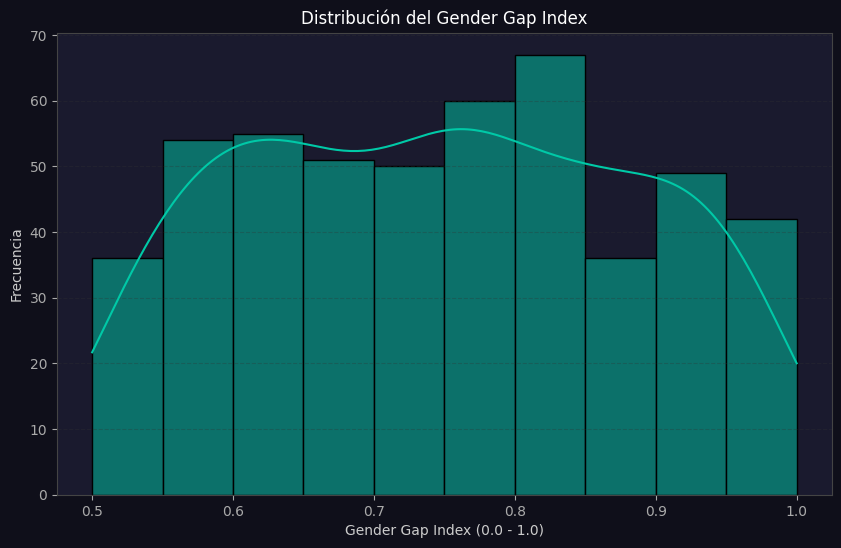

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Gender Gap Index'], kde=True, color=TEAL)
plt.title('Distribución del Gender Gap Index')
plt.xlabel('Gender Gap Index (0.0 - 1.0)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

> **Analisis**

Los datos están distribuidos a lo largo de todo el rango (0.5 a 1.0), no tiene un sesgo fuerte hacia un solo extremo. Significa que a la hora de modelar el modelo va a aprender ejemplos de países/años con brechas altas (0.5-0.6), medias (0.7-0.8) y bajas (0.9-1.0).

La mayor concentración se encuentra cerca del 0.8, lo cual es un indicador positivo de que la mayoría de tus registros reflejan una tendencia hacia la paridad, pero hay suficiente variabilidad para que el modelo aprenda a distinguir casos "difíciles" (los que están cerca de 0.5).

> ## <font color='#1890A3'>**LinePlot de Gender Gap Index vs STEM field en el tiempo**</font>

**Objetivo:** Entender como se ha comportado el Gender Gap Index por campo STEM en el periodo de estudio

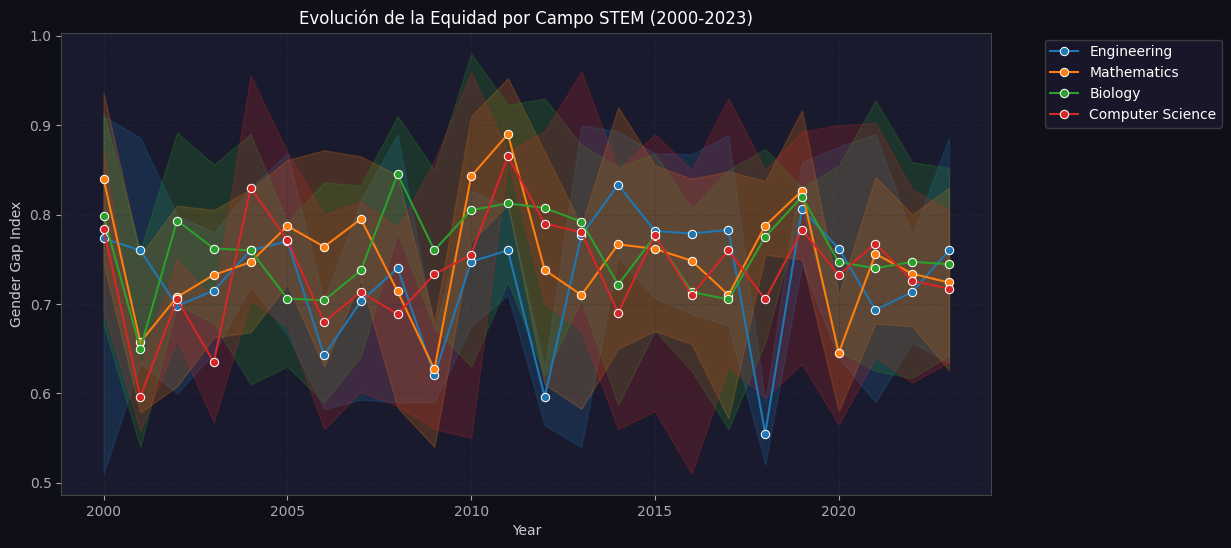

In [19]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x='Year', y='Gender Gap Index', hue='STEM Fields', marker='o')
plt.title('Evolución de la Equidad por Campo STEM (2000-2023)')
plt.ylabel('Gender Gap Index')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

> **Analisis**

No se observa una tendencia al alza o ala baja constante, los indices fluctuan año tras año. Esto sugiere que el `Gender Gap Index` está sujeto a factores externos, políticas temporales o cambios en la metodología de reporte de datos en lugar de un progreso educativo acumulativo estable.

Las áreas sombreadas que representan la variabilidad o el error estándar)son muy amplias. Esto significa que dentro de un mismo año, hay una diferencia enorme entre los países con mejor y peor desempeño.

Se obsevan caídas bruscas en años como 2009, 2012 o 2018. Esto indica que los sistemas educativos son muy sensibles a cambios en el entorno socioeconómico de cada pais

> ## <font color='#1890A3'>**HeatMap de variables Numericas**</font>

**Objetivo:** Entender la correlacion de las variables con `Gender Gap Index`

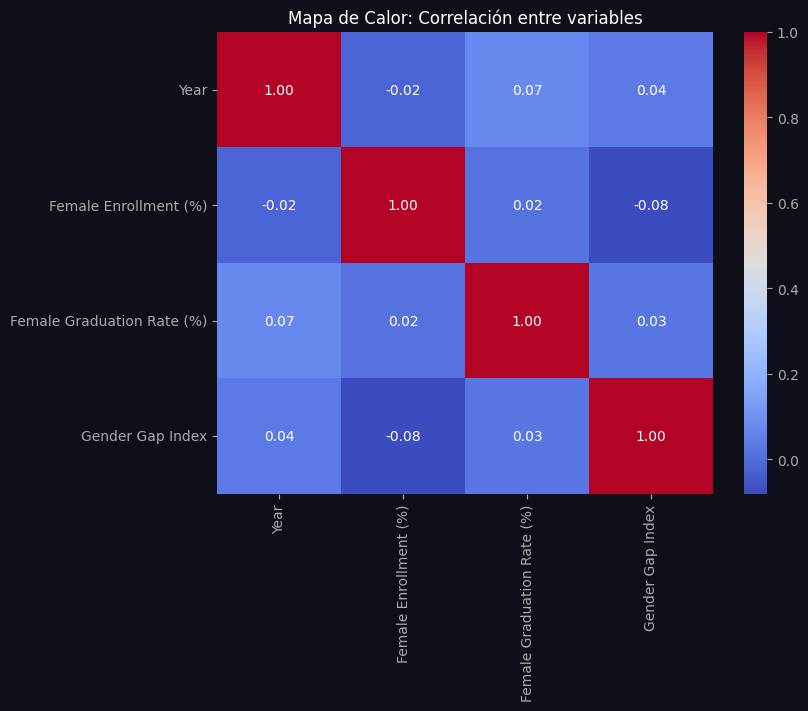

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.select_dtypes(include=['float64', 'int64']).corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor: Correlación entre variables')
plt.show()

> **Analisis**

Las variables no tienen relación lineal con `Gender Gap Index`: `Year` (0.04), `Female Enrollment %` (-0.08) y `Female Graduation Rate %` (0.03).

Esto significa que el progreso hacia la equidad no es un proceso lineal simple, es un proceso complejo afectado por diversos factores que las variables actuales no capturan completamente.


> ## <font color='#1890A3'>**RegPlot entre Female Enrollment y Female Graduation rates**</font>

**Objetivo:** Analizar si el incremento en Enrollment se traduce realmente en mejores tasas de graduación.

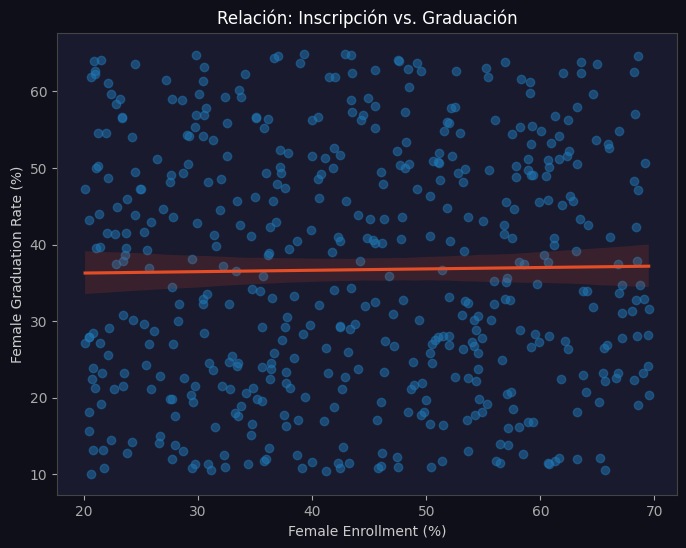

In [22]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df_clean, x='Female Enrollment (%)', y='Female Graduation Rate (%)',
            scatter_kws={'alpha':0.5}, line_kws={'color':RED})
plt.title('Relación: Inscripción vs. Graduación')
plt.xlabel('Female Enrollment (%)')
plt.ylabel('Female Graduation Rate (%)')
plt.show()

> **Analisis**

El gráfico muestra una nube de puntos totalmente dispersa y una línea de regresión casi horizontal (pendiente cercana a cero). Esto significa que NO existe una relación lineal entre Inscripción y Graduación: El hecho de que aumente el porcentaje de mujeres que se inscriben en una carrera STEM no garantiza que aumente el porcentaje de mujeres que se gradúan.

Esto significa que los factores que llevan a una mujer a inscribirse en una carrera STEM (promoción, becas, interés, etc) son completamente distintos de los factores que la llevan a graduarse (calidad docente, apoyo académico, barreras culturales, costo durante la carrera).

#**📊 Hallazgos y Desafios**

##1. **Hallazgos Clave**

***Distribución del Índice de Equidad:*** Se identificó una distribución amplia y heterogénea (0.5 a 1.0) en el Gender Gap Index. Esto indica que el dataset cuenta con una base diversa que permite entrenar modelos con escenarios tanto de baja como de alta paridad.

***Progreso Temporal Variable:*** El análisis longitudinal (2000-2023) reveló que el progreso no es lineal ni constante. Se observan fluctuaciones significativas año tras año, lo que sugiere que la equidad en STEM está fuertemente influenciada por factores externos y no solo por la inercia del sistema educativo.

***Desconexión Inscripción-Graduación:*** La relación entre el porcentaje de Enrollment y Graduation Rate es practicamente nula. Aumentar la base de ingreso no garantiza, por sí solo, un aumento en la tasa de egresados.

***Ausencia de Correlación Lineal:*** Las variables analizadas no presentan correlaciones lineales fuertes entre sí, lo que confirma que el fenómeno de la brecha de género es multicausal y complejo.

##**2. Características del Dataset**

***Integridad:*** El dataset cuenta con 500 registros limpios, sin valores nulos.

***Diversidad:*** Contempla 6 países y 4 disciplinas STEM, ofreciendo suficiente variabilidad para realizar análisis segmentados por país o campo.

***Organizacion y veracidad:*** La distribución de los datos sugiere que provienen de reportes reales, sin manipulación artificial, manteniendo la riqueza del fenómeno social.

##**3. Desafíos para el Modelado**

***No Linealidad:*** Debido a la falta de correlación lineal clara, no se debe usar Regresion Lineal simple. El mayor reto será capturar relaciones condicionales complejas.

***Sensibilidad al Contexto:*** La alta volatilidad observada exige que el modelo sea capaz de gestionar el "ruido". La simple tendencia temporal es insuficiente para predecir el 2030 con alta precisión.

***Necesidad de Ingeniería de Variables:*** El éxito del modelo dependerá de la creación de nuevas características (features) que actúen como "puentes", como el Ratio de Eficiencia Académica (Graduación/Inscripción), para proporcionar al modelo datos más claras que las variables crudas.

>**Conclusión:** El dataset es robusto y está listo para ser mmodelado, pero requiere un enfoque basado en modelos no lineales (como Random Forest o XGBoost) y una ingeniería de variables inteligente para transformar los datos brutos en indicadores predictivos de valor estratégico.